In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/cleaned/uber_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (195065, 11)


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,Thursday,5,2015
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,Friday,7,2009
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,Monday,8,2009
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,Friday,6,2009
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,Thursday,8,2014


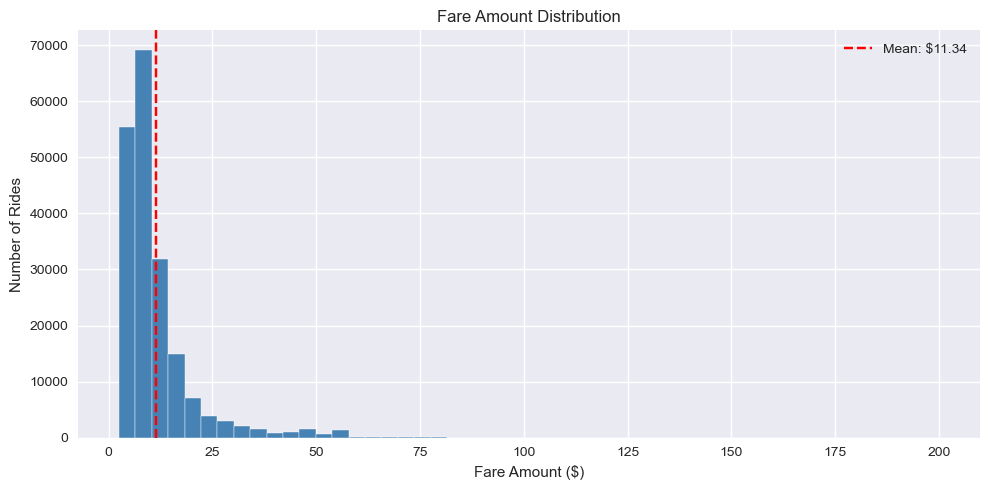

Average fare: 11.34
Median fare: 8.5
Most common fare range: $5 - $15


In [3]:
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white')
plt.title('Fare Amount Distribution')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Rides')
plt.axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f"Mean: ${df['fare_amount'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print("Average fare:", round(df['fare_amount'].mean(), 2))
print("Median fare:", round(df['fare_amount'].median(), 2))
print("Most common fare range: $5 - $15")

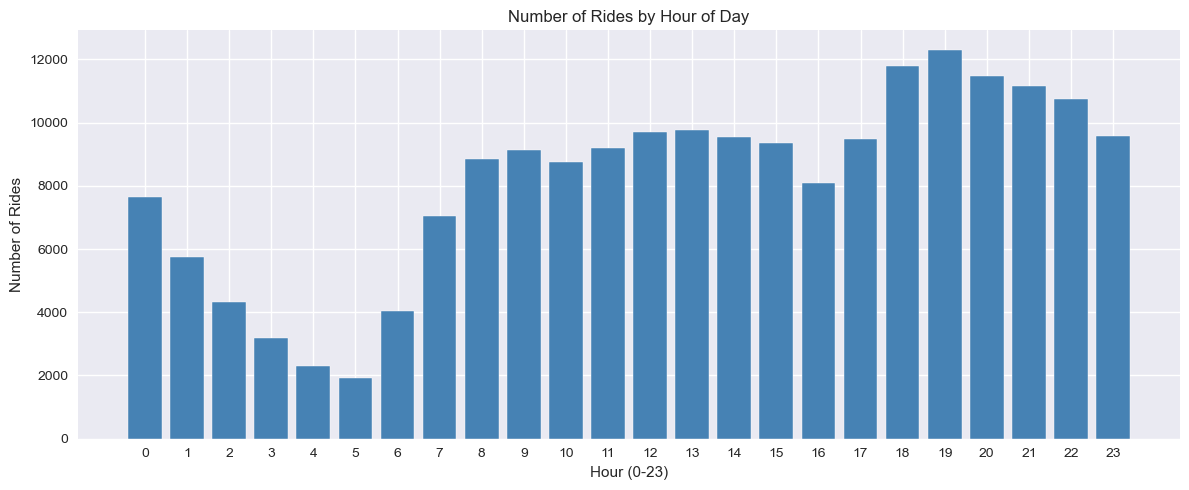

In [4]:
plt.figure(figsize=(12, 5))
hourly = df.groupby('hour')['fare_amount'].count()
plt.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
plt.title('Number of Rides by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

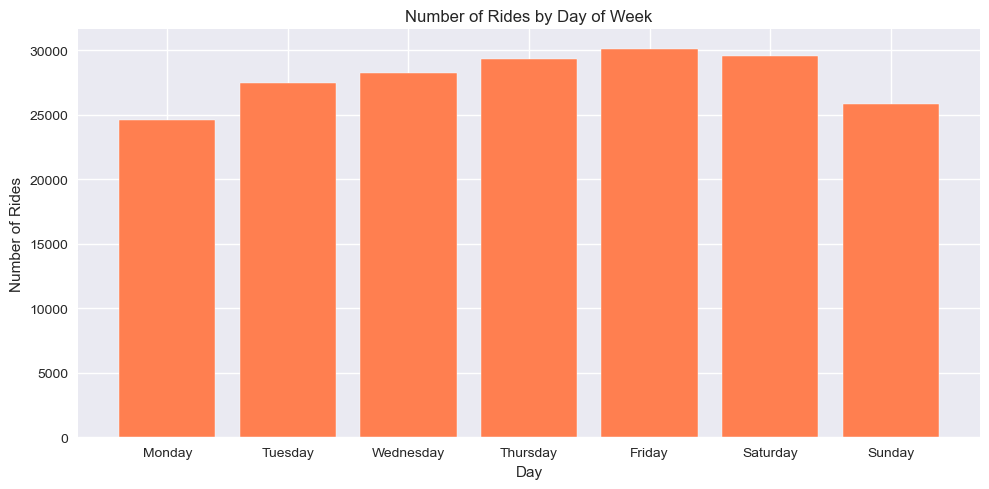

In [5]:
plt.figure(figsize=(10, 5))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
plt.bar(day_counts.index, day_counts.values, color='coral', edgecolor='white')
plt.title('Number of Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

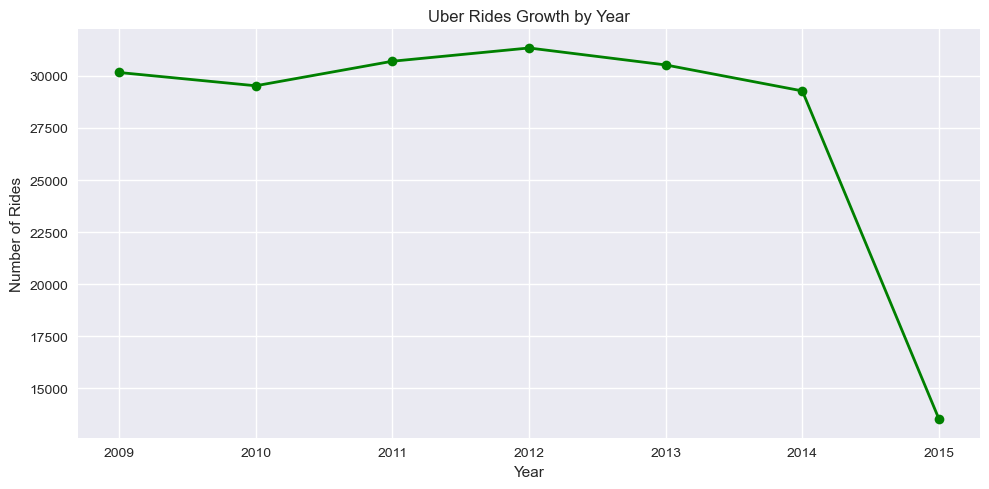

In [6]:
plt.figure(figsize=(10, 5))
year_counts = df.groupby('year')['fare_amount'].count()
plt.plot(year_counts.index, year_counts.values, marker='o', color='green', linewidth=2)
plt.title('Uber Rides Growth by Year')
plt.xlabel('Year')
plt.ylabel('Number of Rides')
plt.grid(True)
plt.tight_layout()
plt.show()

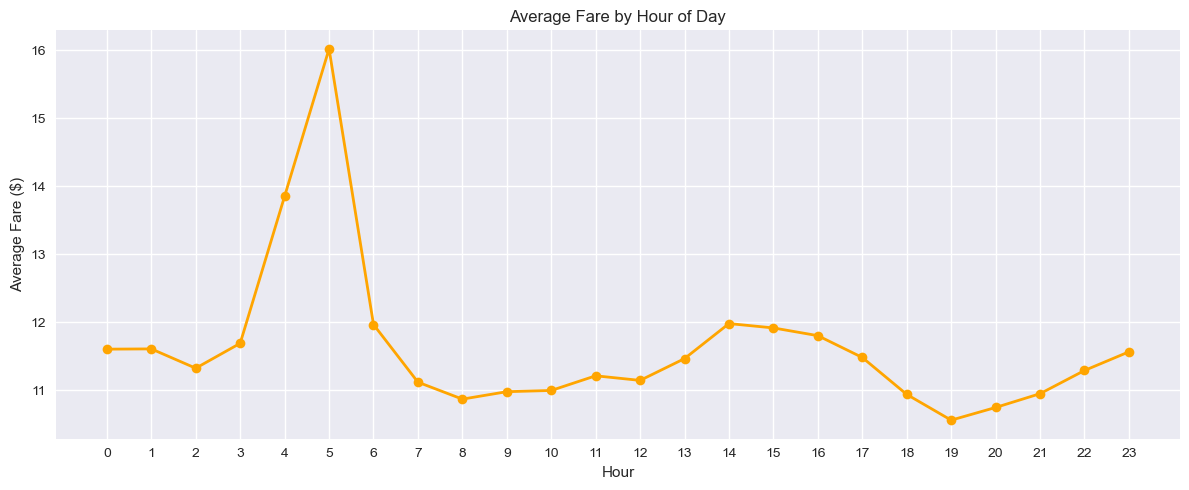

In [7]:
plt.figure(figsize=(12, 5))
avg_fare_hour = df.groupby('hour')['fare_amount'].mean()
plt.plot(avg_fare_hour.index, avg_fare_hour.values, marker='o', color='orange', linewidth=2)
plt.title('Average Fare by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Fare ($)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

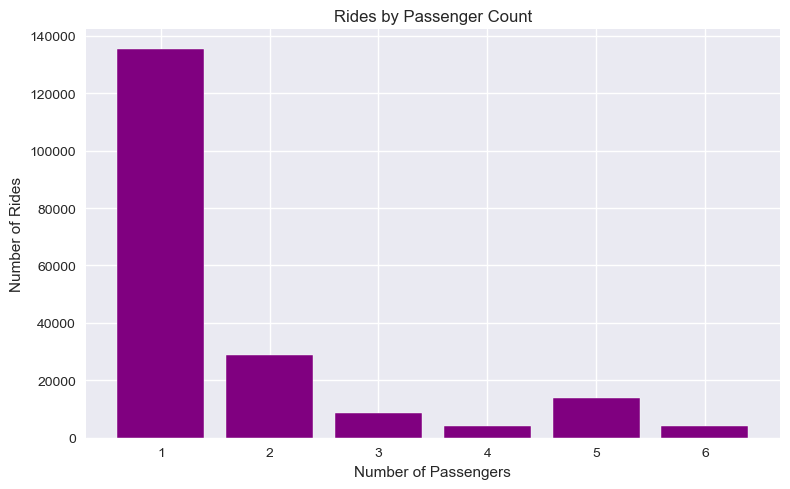

In [8]:
plt.figure(figsize=(8, 5))
passenger = df['passenger_count'].value_counts().sort_index()
plt.bar(passenger.index, passenger.values, color='purple', edgecolor='white')
plt.title('Rides by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Number of Rides')
plt.tight_layout()
plt.show()

C:\Users\addys\AppData\Local\Temp\ipykernel_3912\2252785803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='fare_amount', data=df, palette='husl')


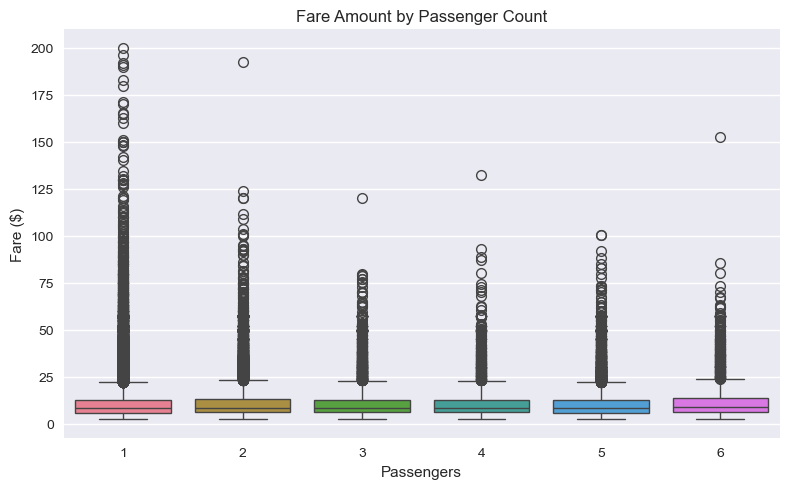

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='passenger_count', y='fare_amount', data=df, palette='husl')
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passengers')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()

In [10]:
print("=== KEY INSIGHTS ===")
print(f"Peak hour: {df.groupby('hour')['fare_amount'].count().idxmax()}:00")
print(f"Busiest day: {df['day_of_week'].value_counts().index[0]}")
print(f"Best year for rides: {df.groupby('year')['fare_amount'].count().idxmax()}")
print(f"Most common passenger count: {df['passenger_count'].mode()[0]}")
print(f"Average fare: ${df['fare_amount'].mean():.2f}")
print(f"Highest avg fare hour: {df.groupby('hour')['fare_amount'].mean().idxmax()}:00")

=== KEY INSIGHTS ===
Peak hour: 19:00
Busiest day: Friday
Best year for rides: 2012
Most common passenger count: 1
Average fare: $11.34
Highest avg fare hour: 5:00
